Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Clone Repository

In [3]:
!git clone https://github.com/shefiramarizcha62-sudo/Deep-Learning-for-Predictive-Maintenance-in-IIoT-Automation-.git

Cloning into 'Deep-Learning-for-Predictive-Maintenance-in-IIoT-Automation-'...
remote: Enumerating objects: 120, done.
remote: Counting objects: 100% (120/120), done.
remote: Compressing objects: 100% (110/110), done.
remote: Total 120 (delta 37), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (120/120), 2.67 MiB | 5.73 MiB/s, done.
Resolving deltas: 100% (37/37), done.


Masuk ke Folder Project

In [4]:
%cd Deep-Learning-for-Predictive-Maintenance-in-IIoT-Automation-

/content/Deep-Learning-for-Predictive-Maintenance-in-IIoT-Automation-


Cek Isi Folder

In [5]:
ls

data/  docs/  notebooks/  README.md  requirements.txt  results/  src/


Import Library

In [6]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt

Load Dataset

In [7]:
columns = ['unit_number','time_in_cycles',
           'op_setting_1','op_setting_2','op_setting_3']

sensor_columns = [f'sensor_{i}' for i in range(1,22)]

columns.extend(sensor_columns)

train_df = pd.read_csv(
    'data/train_FD001.txt',
    sep='\s+',
    header=None
)

train_df = train_df.iloc[:,:26]

train_df.columns = columns

train_df.head()

<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_989/2593744736.py:10: SyntaxWarning: invalid escape sequence '\s'
  sep='\s+',


,unit_number,time_in_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


Hitung RUL

In [8]:
rul = train_df.groupby('unit_number')['time_in_cycles'].max()

train_df = train_df.merge(
    rul.to_frame(name='max_cycle'),
    on='unit_number'
)

train_df['RUL'] = (
    train_df['max_cycle']
    - train_df['time_in_cycles']
)

Piece-wise RUL

In [9]:
max_rul = 125

train_df['RUL'] = train_df['RUL'].clip(upper=max_rul)

Feature Selection

In [10]:
sensor_cols = sensor_columns

train_df[sensor_cols].std().sort_values()

,0
sensor_19,0.000000e+00
sensor_18,0.000000e+00
sensor_16,1.556432e-14
sensor_10,4.660829e-13
sensor_5,3.394700e-12
sensor_1,6.537152e-11
sensor_6,1.388985e-03
sensor_15,3.750504e-02
sensor_8,7.098548e-02
sensor_13,7.191892e-02


In [ ]:
drop_sensors = [
    'sensor_1',
    'sensor_5',
    'sensor_10',
    'sensor_16',
    'sensor_18',
    'sensor_19'
]

train_df = train_df.drop(columns=drop_sensors)

Normalization

In [11]:
features = train_df.columns.difference([
    'unit_number',
    'time_in_cycles',
    'RUL',
    'max_cycle'
])

scaler = MinMaxScaler()

train_df[features] = scaler.fit_transform(
    train_df[features]
)

Denoising

In [12]:
train_df['sensor_2_smooth'] = (
    train_df.groupby('unit_number')['sensor_2']
    .transform(lambda x: x.rolling(5).mean())
)

In [13]:
train_df = train_df.fillna(method='bfill')

/tmp/ipykernel_989/1550443520.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train_df = train_df.fillna(method='bfill')


VISUALISASI BEFORE/AFTER SMOOTHING

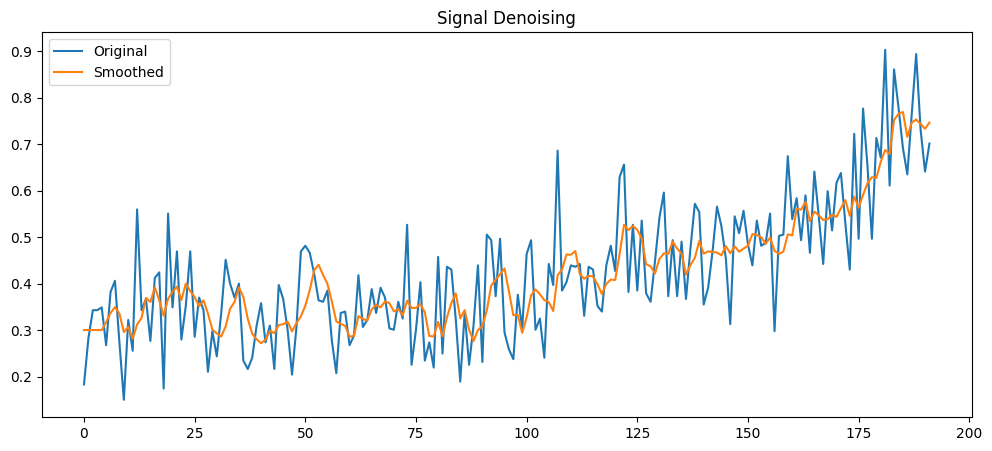

In [14]:
engine_1 = train_df[train_df['unit_number']==1]

plt.figure(figsize=(12,5))

plt.plot(engine_1['sensor_2'], label='Original')
plt.plot(engine_1['sensor_2_smooth'], label='Smoothed')

plt.legend()
plt.title('Signal Denoising')
plt.show()

Sequence Generation

Sequence Length

In [15]:
sequence_length = 30

Function

In [16]:
def create_sequences(data, seq_length, feature_cols):

    X = []
    y = []

    for unit in data['unit_number'].unique():

        unit_df = data[data['unit_number']==unit].copy()

        for i in range(len(unit_df)-seq_length):

            seq_x = unit_df[feature_cols].iloc[
                i:i+seq_length
            ].values

            seq_y = unit_df['RUL'].iloc[
                i+seq_length
            ]

            X.append(seq_x)
            y.append(seq_y)

    return np.array(X), np.array(y)

Generate Sequence

In [17]:
feature_cols = features.tolist()

X_train, y_train = create_sequences(
    train_df,
    sequence_length,
    feature_cols
)

print(X_train.shape)
print(y_train.shape)

(17631, 30, 24)
(17631,)


Save Hasil

In [18]:
np.save('data/X_train.npy', X_train)
np.save('data/y_train.npy', y_train)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (17631, 30, 24)
y_train shape: (17631,)


# BASELINE 1D-CNN

TRAIN VALIDATION SPLIT

In [19]:
from sklearn.model_selection import train_test_split

X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42
)

IMPORT TENSORFLOW

In [22]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Conv1D
from tensorflow.keras.layers import MaxPooling1D
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

BUILD MODEL

In [23]:
model = Sequential()

model.add(
    Conv1D(
        filters=64,
        kernel_size=3,
        activation='relu',
        input_shape=(
            X_train_split.shape[1],
            X_train_split.shape[2]
        )
    )
)

model.add(MaxPooling1D(pool_size=2))

model.add(
    LSTM(
        64,
        return_sequences=False
    )
)

model.add(Dropout(0.3))

model.add(Dense(50, activation='relu'))

model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


COMPILE

In [24]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 28, 64)         │         4,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         3,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,997 (160.14 KB)

 Trainable params: 40,997 (160.14 KB)

 Non-trainable params: 0 (0.00 B)

TRAINING

In [25]:
history = model.fit(
    X_train_split,
    y_train_split,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val)
)

Epoch 1/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 3485.8215 - mae: 49.4895 - val_loss: 1755.8234 - val_mae: 37.2699
Epoch 2/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 1653.5248 - mae: 35.9318 - val_loss: 1213.8627 - val_mae: 31.3204
Epoch 3/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 796.4882 - mae: 24.0300 - val_loss: 433.7136 - val_mae: 17.1876
Epoch 4/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 480.8450 - mae: 17.5516 - val_loss: 376.7516 - val_mae: 15.3061
Epoch 5/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - loss: 409.1674 - mae: 16.1047 - val_loss: 301.1021 - val_mae: 13.2726
Epoch 6/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 345.1385 - mae: 14.6598 - val_loss: 248.1080 - val_mae: 12.1699
Epoch 7/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - loss: 314.5537 - mae: 13.8915 - val_loss: 236.5098 - val_mae: 11.5295
Epoch 8/20
221/221 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 292.3072 - mae: 13.3158 - val_loss: 239.4090 - val_mae: 11.7

EVALUASI

In [26]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

pred = model.predict(X_val)

rmse = np.sqrt(
    mean_squared_error(y_val, pred)
)

mae = mean_absolute_error(y_val, pred)

print("RMSE:", rmse)
print("MAE :", mae)

111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
RMSE: 13.24827650844954
MAE : 9.681782722473145


In [28]:
import pandas as pd

comparison = pd.DataFrame({

    'Model': ['1D-CNN', 'CNN-LSTM'],
    'RMSE': [14.46, rmse],
    'MAE': [11.00, mae]
})

comparison

,Model,RMSE,MAE
0,1D-CNN,14.460000,11.000000
1,CNN-LSTM,13.248277,9.681783


PLOT LOSS

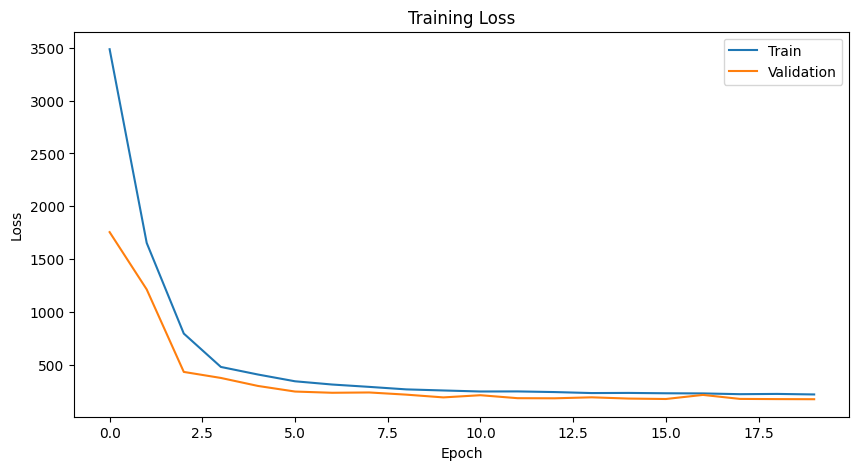

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Training Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train','Validation'])

plt.show()

PLOT PREDICTION

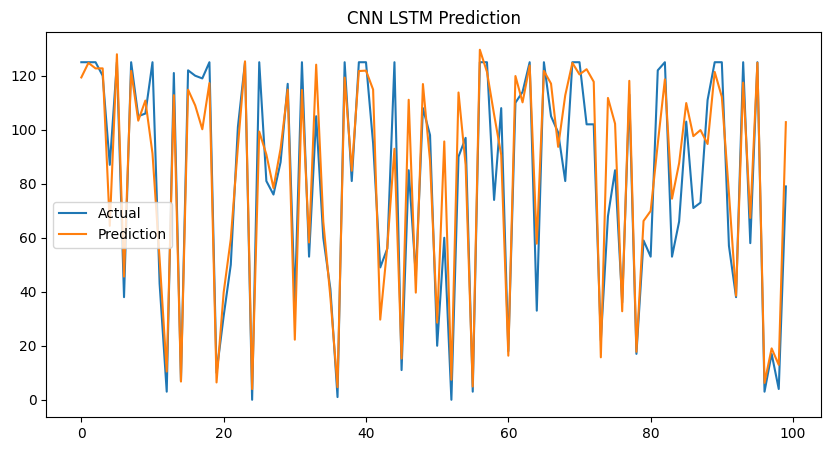

In [33]:
plt.figure(figsize=(10,5))

plt.plot(y_val[:100], label='Actual')
plt.plot(pred[:100], label='Prediction')

plt.legend()

plt.title('CNN LSTM Prediction')

plt.show()

SAVE MODEL CNN-LSTM

In [31]:
model.save(
    'results/models/cnn_lstm_model.keras'
)

SAVE METRIC CNN-LSTM

In [32]:
with open(
    'results/metrics/cnn_lstm_results.txt',
    'w'
) as f:

    f.write(f'RMSE: {rmse}\n')
    f.write(f'MAE : {mae}\n')

MODEL SUMMARY

In [34]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 28, 64)         │         4,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         3,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,993 (480.45 KB)

 Trainable params: 40,997 (160.14 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 81,996 (320.30 KB)